#### Auto Reloading for External Libraries

In [1]:
import numpy as np
from tqdm import tqdm
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Using this magic command, we turn on auto-reloading for libraries imported by %aimport
%load_ext autoreload
%autoreload 2
%aimport Sub
%aimport Master
%aimport DataPreparation

## 2. lp Box ADMM

In [4]:
# Microgrids data
from DataPreparation import getMGData, getCEMSData
N = 3
T = 24
mg_private, mg_public = {}, {}
for n in range(N):
    mg_private[n], mg_public[n] = getMGData(N, n, T)
cems = getCEMSData(N, T, mg_public, mg_private)

# Build models
from Sub import Sub
from Master import Master
f = [Sub(data=mg_private[i], trade=True, MIP=False) for i in range(N)]
g = Master(data=cems)
name = f'RPADMM(t={f[0].config.tau})'

Set parameter Username
Set parameter LicenseID to value 2625858
Academic license - for non-commercial use only - expires 2026-02-20
Set parameter Method to value 0


In [33]:
def retract(v, c, r):
    temp = v - c
    temp_norm = np.linalg.norm(temp, axis=1)
    temp_unit = np.array([nom / denom for nom, denom in zip(temp, temp_norm)])
    return c + r * temp_unit

In [146]:
# Parameters
y_shape, x_shape = g.yhat.shape, (N, T)
yhat, l_y = 100 * np.ones(y_shape), np.zeros(y_shape)
z, l_z = np.zeros(x_shape), np.zeros(x_shape)
c, r = 0.5 * np.ones((N, T)), np.sqrt(T)/2
rho_y, rho_z = 1e-8, 100
mu, tau = 10, 2
gamma, eta = 100000, 0.018
decay = 0.98
e_y, e_z = 0.5, 0.5

In [147]:
# RP-ADMM
from time import time
yhat_, z_ = yhat, z
prs, drs = [], []
itr = 0
max_itr = 2500
start = time()
for itr in tqdm(range(max_itr),desc='Progress'):
    # Solve f
    y, x = [], []
    for i, fi in enumerate(f):
        kwargs = {
            'yhat': yhat[:, i, :, :],
            'l_y': l_y[:, i, :, :],
            'rho_y': rho_y,
            'z': z[i, :],
            'l_z': l_z[i, :],
            'rho_z': rho_z,
            }
        yi, xi = fi.solve_with(**kwargs)
        y.append(yi)
        x.append(xi)
    y = np.transpose(np.stack(y, axis=0), (1, 0, 2, 3))
    x = np.stack(x, axis=0)

    # Solve g
    yhat = g.solve_with(y=y, rho_y=rho_y, l_y=l_y)

    # Update z
    lagrang_G = -l_z - rho_z * (x - z)
    penalty_G = gamma * (np.minimum(2 * z, 0) + np.maximum(2 * (z - 1), 0))
    G = lagrang_G + penalty_G
    v = z - c
    r2 = r ** 2
    vvT = np.array([vi[:, None] @ vi[:, None].T for vi in v])
    vvT /= r2
    vvTG = np.array([vvTi @ Gi for Gi, vvTi in zip(G, vvT)])
    grad_g = G - vvTG
    z -= eta * grad_g
    z = retract(z, c, r)

    # Gradient descent
    l_y += rho_y * (y - yhat)
    l_z += rho_z * (x - z)

    # Residuals
    pr = [np.linalg.norm(y - yhat), np.linalg.norm(x - z)]
    dr = [rho_y * np.linalg.norm(yhat - yhat_), rho_z * np.linalg.norm(z - z_)]
    done = all([pr[0]+dr[0] <= e_y, pr[1]+dr[1] <= e_z])
    (prs.append(pr), drs.append(dr))

    # Update itr
    itr += 1
    yhat_, z_ = yhat, z

    # Update rhos
    y_coef = tau if pr[0] >= mu * dr[0] else 1 / tau if dr[0] >= mu * pr[0] else 1
    z_coef = tau if pr[1] >= mu * dr[1] else 1 / tau if dr[1] >= mu * pr[1] else 1
    rho_y, rho_z = y_coef * rho_y, z_coef * rho_z
    eta *= decay if itr%10 == 0 else 1

    # Terminate
    if done:
        break
print(time() - start)

Progress: 100%|██████████| 2500/2500 [06:47<00:00,  6.13it/s]

407.80185747146606


In [136]:
print(dr[0]+pr[0], pr[1]+dr[1])

2.9393876913398135e-05 0.0


In [149]:
f[0].eta_r

<gurobi.Var eta_r (value 0.5986773960394034)>

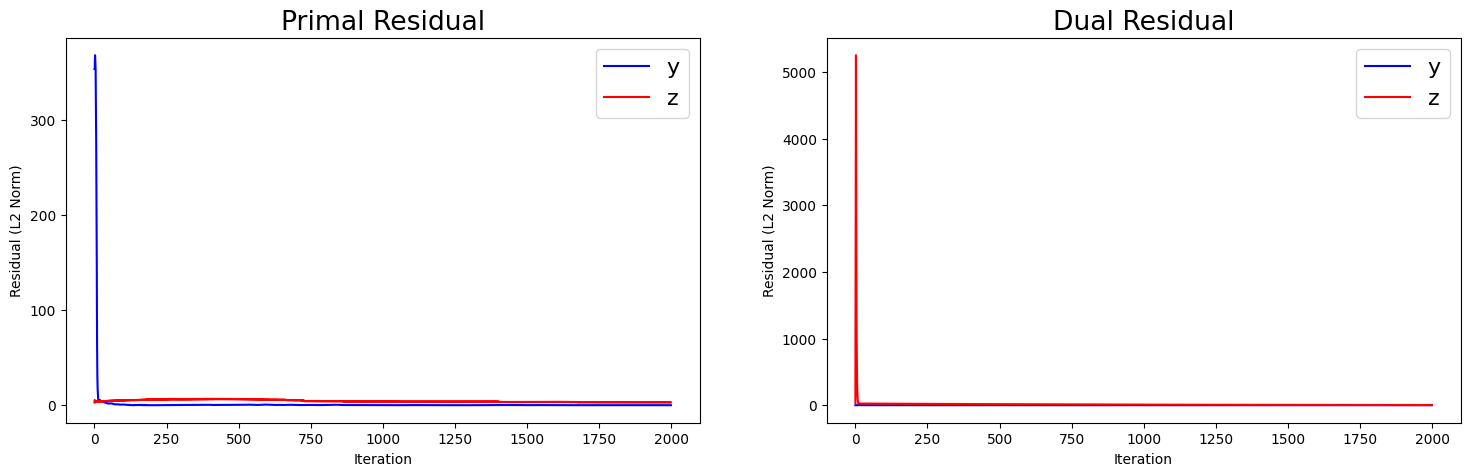

In [95]:
import matplotlib.pyplot as plt
y_primal, y_dual = np.stack(prs, axis=1), np.stack(drs, axis=1)

fig, axs = plt.subplots(1, 2, figsize=(18, 5))
plt.rcParams['font.size'] = 16
plt.subplots_adjust(hspace=0.6)

axs[0].plot(y_primal[0], label='y', color='blue')
axs[0].plot(y_primal[1], label='z', color='red')
axs[0].set_title('Primal Residual')

axs[1].plot(y_dual[0], label='y', color='blue')
axs[1].plot(y_dual[1], label='z', color='red')
axs[1].set_title('Dual Residual')
for ax in axs:
    ax.legend()
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Residual (L2 Norm)')

plt.savefig(f'Performance/residuals.jpg', dpi=600)

In [150]:
for n in range(N):
    kwargs = {
            'yhat': yhat[:, n, :, :],
            'l_y': l_y[:, n, :, :],
            'rho_y': rho_y,
            'z': z[n, :],
            'l_z': l_z[n, :],
            'rho_z': rho_z,
            }
    f[n].save_solutions(**kwargs, name=name)

In [5]:
from Results import *
name_to_save = f'RPADMM(t={f[0].config.tau})_'
results0 = {n: MGResults(f'NoTrade_MG({n})', mg_private[n]) for n in range(N)}
results1 = {n: MGResults(f'{name_to_save}MG({n})', mg_private[n]) for n in range(N)}

In [8]:
# Cost table
get_cost_table(results0, results1, N, name_to_save)

# Resilience and cost reduction
get_metric_table(results0, results1, N, name_to_save)

# KPI
get_kpi_table(results1, N, name_to_save)

# Power table
get_power_table(results1, N, name_to_save)

# Trade plot
plot_trade(results1, name_to_save)

# Load satisfaction plot
plot_load_served(results1, 1, name_to_save)

# plot
plot_trade(results1, name_to_save)
plot_demand(results0, results1, name_to_save)

In [17]:
plot_demand(results0, results1, name_to_save)

### lp-ADMM

In [148]:
y_shape, x_shape = g.yhat.shape, (N, T)
yhat, l_y = 100 * np.ones(y_shape), np.zeros(y_shape)
z1, l_z1 = np.zeros(x_shape), np.zeros(x_shape)
z2, l_z2 = np.zeros(x_shape), np.zeros(x_shape)
c, r = 0.5 * np.ones((N, T)), np.sqrt(T)/2
rho_y, rho_z1, rho_z2 = 1e-8, 10, 10
mu, tau = 10, 2
gamma, eta = 10000, 0.01
decay = 0.98
e_y, e_z = 0.5, 0.5

In [149]:
# MP-ADMM
from time import time
yhat_, z1_, z2_ = yhat, z1, z2
prs, drs = [], []
itr = 0
max_itr = 2000
start = time()
for itr in tqdm(range(max_itr)):
    # Solve f
    y, x = [], []
    for i, fi in enumerate(f):
        kwargs = {
            'yhat': yhat[:, i, :, :],
            'l_y': l_y[:, i, :, :],
            'rho_y': rho_y,
            'z1': z1[i, :],
            'l_z1': l_z1[i, :],
            'rho_z1': rho_z1,
            'z2': z2[i, :],
            'l_z2': l_z2[i, :],
            'rho_z2': rho_z2,
            }
        yi, xi = fi.solve_with_lp(**kwargs)
        y.append(yi)
        x.append(xi)
    y = np.transpose(np.stack(y, axis=0), (1, 0, 2, 3))
    x = np.stack(x, axis=0)

    # Solve g
    yhat = g.solve_with(y=y, rho_y=rho_y, l_y=l_y)

    # Update z1
    z1 = np.clip(z1 + l_z1/rho_z1, 0, 1)

    # Update z2
    z2 = retract(z2 + l_z2/rho_z2, c, r)

    # Gradient descent
    l_y += rho_y * (y - yhat)
    l_z1 += rho_z1 * (x - z1)
    l_z2 += rho_z2 * (x - z2)

    # Residuals
    pr = [np.linalg.norm(y - yhat), np.linalg.norm(x - z1), np.linalg.norm(x - z2)]
    dr = [rho_y * np.linalg.norm(yhat - yhat_), rho_z1 * np.linalg.norm(z1 - z1_), rho_z2 * np.linalg.norm(z2 - z2_)]
    done = all([pr[0] + dr[0] <= e_y, pr[1] + dr[1] <= e_z, pr[2] + dr[2] <= e_z])
    (prs.append(pr), drs.append(dr))

    # Update itr
    itr += 1
    yhat_, z1_, z2_ = yhat, z1, z2

    # Update rhos
    y_coef = tau if pr[0] >= mu * dr[0] else 1 / tau if dr[0] >= mu * pr[0] else 1
    z1_coef = tau if pr[1] >= mu * dr[1] else 1 / tau if dr[1] >= mu * pr[1] else 1
    z2_coef = tau if pr[2] >= mu * dr[2] else 1 / tau if dr[2] >= mu * pr[2] else 1
    rho_y, rho_z1, rho_z2 = y_coef * rho_y, z1_coef * rho_z1, z2_coef * rho_z2
    eta *= decay if itr%10 == 0 else 1

    # Terminate
    if done:
        break
print(time() - start)

100%|██████████| 2000/2000 [02:20<00:00, 14.28it/s]

140.03819870948792


In [150]:
print(dr[0]+pr[0], pr[1]+pr[2]+dr[1]+dr[2])

0.04578798436112701 32.757965197844435
